In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

In [3]:
from dataset import SuctionGraspingDataset

In [5]:
dataset = SuctionGraspingDataset(
    data_path='../data',
    sample_list='../data/train-split.txt',
    output_scale=8,
    img_height=480,
    img_width=640,
)

# Use batch_size workers for multi‑threading as in the original code
loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=True,  # UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
)

for color_batch, depth_batch, label_batch in loader:
    print(color_batch.shape) # color_batch:  (B, 3, H, W)
    print(depth_batch.shape) # depth_batch:  (B, 3, H, W)
    print(label_batch.shape) # label_batch:  (B, H//8, W//8)
    break

c:\Users\iceland\Documents\Labwave\arc-robot-vision-python\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([4, 3, 480, 640])
torch.Size([4, 3, 480, 640])
torch.Size([4, 60, 80])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].


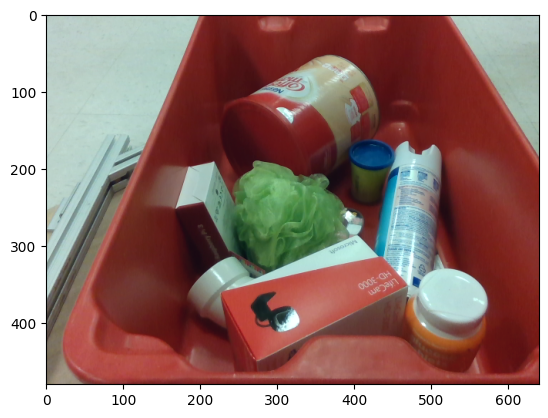

In [14]:
plt.imshow(torch.movedim(color_batch[1] * 0.229 + 0.485, 0, 2))

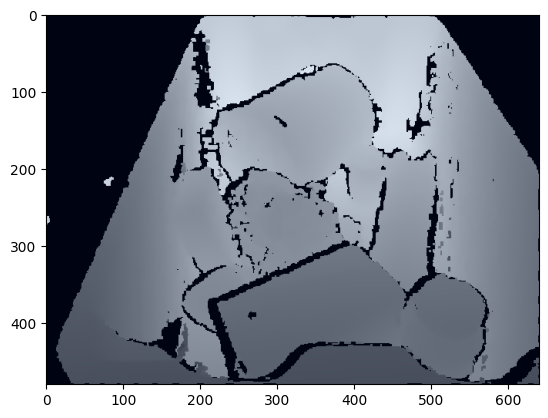

In [15]:
plt.imshow(torch.movedim(depth_batch[1] * 0.229 + 0.485, 0, 2))

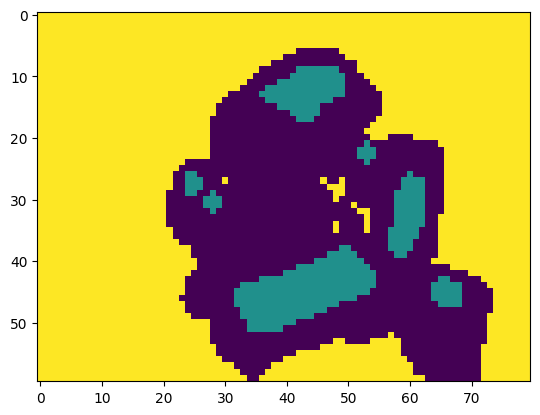

In [16]:
plt.imshow((label_batch[1] - 1) / 2)